# Rock–Paper–Scissors with Bayesian Learning and Hidden Markov Model

## Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## General setup

In [2]:
rng = np.random.default_rng(5058)

# 0 - Tie
# 1 - First wins
# 2 - Second wins
def define_winner(first_choice, second_choice):
    result = (first_choice - second_choice) % 3
    return 1 if result == 1 else -1 if result == 2 else 0

## Opponent setup

In [3]:
def generate_transition_matrix():
    matrix = rng.random((3, 3))
    return matrix / matrix.sum(axis=1, keepdims=True)

opponent_matrix = generate_transition_matrix()

def get_opponent_move(previous): return rng.choice(3, p = opponent_matrix[previous])

## Learner setup

In [4]:
learner_matrix = np.ones((3, 3))

def normalize_learner_matrix(): return learner_matrix / learner_matrix.sum(axis=1, keepdims=True)
def predict_opponent_move(previous): return np.argmax(normalize_learner_matrix()[previous])
def get_learner_move(previous): return (predict_opponent_move(previous) + 1) % 3
def update_learner_matrix(previous, current): learner_matrix[previous][current] += 1

## Statistics

In [5]:
stats = {"draws": 0, "learner_wins": 0, "opponent_wins": 0}

def update_wins_quantities(result):
    if result == 0: stats["draws"] += 1
    elif result == 1: stats["learner_wins"] += 1
    elif result == -1: stats["opponent_wins"] += 1

scores = []
cumulative_score = 0

def update_net_advantage(result):
    global cumulative_score
    cumulative_score += result
    scores.append(cumulative_score)

def update_stats(result):
    update_net_advantage(result)
    update_wins_quantities(result)

## Simulation

In [6]:
games_amount = 10_000
opponent_previous = rng.integers(0, 3)

for _ in range (games_amount):
    opponent_current = get_opponent_move(opponent_previous)
    outcome = define_winner(get_learner_move(opponent_previous), opponent_current)

    update_learner_matrix(opponent_previous, opponent_current)
    update_stats(outcome)

    opponent_previous = opponent_current


## Plotting

In [7]:
def plot_net_advantage():
    plt.plot(scores)
    plt.xlabel("Round")
    plt.ylabel("Accumulated score")
    plt.title("Learner accumulated score over rounds")
    plt.grid(True)
    plt.show()

## Results

================== STATISTICS ==================
Games amount: 10000
Opponent matrix:
[[0.30955753 0.44458359 0.24585888]
 [0.08825709 0.3559514  0.55579151]
 [0.33787733 0.36869453 0.29342814]]
Learner matrix(normalized):
[[0.30810587 0.44871795 0.24317618]
 [0.09690023 0.35660328 0.54649648]
 [0.34701493 0.36886994 0.28411514]]
================== SCORES ==================
Draws: 2044
Learner wins: 4551
Opponent wins: 3405


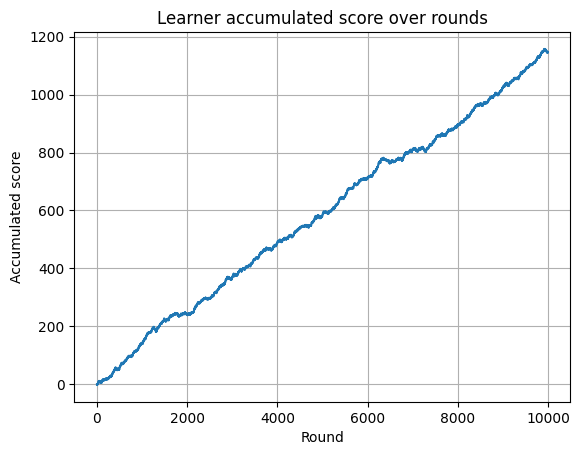

In [8]:
print("================== STATISTICS ==================")
print(f"Games amount: {games_amount}")
print(f"Opponent matrix:\n{opponent_matrix}")
print(f"Learner matrix(normalized):\n{normalize_learner_matrix()}")

print("================== SCORES ==================")
print(f"Draws: {stats['draws']}")
print(f"Learner wins: {stats['learner_wins']}")
print(f"Opponent wins: {stats['opponent_wins']}")

plot_net_advantage()